In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as plt_sns
import seaborn as sns

In [14]:
# Set visualization style
sns.set_theme(style="whitegrid")

In [15]:
# 1. Load the Dataset
df = pd.read_csv("Day13_Restaurant_Branch_Performance_Dataset.csv")

In [16]:
# 2. Basic Information & Summary Statistics
print("--- Dataset Info ---")
print(df.info())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Record_ID         350 non-null    object 
 1   Date              350 non-null    object 
 2   Day               350 non-null    object 
 3   Month             350 non-null    object 
 4   Branch            350 non-null    object 
 5   Region            350 non-null    object 
 6   Store_Type        350 non-null    object 
 7   Staff_Count       350 non-null    int64  
 8   Marketing_Spend   350 non-null    float64
 9   Customers         350 non-null    int64  
 10  Orders            350 non-null    int64  
 11  Average_Bill      350 non-null    float64
 12  Revenue           350 non-null    float64
 13  Food_Cost         350 non-null    float64
 14  Operating_Cost    350 non-null    float64
 15  Profit            350 non-null    float64
 16  Avg_Delivery_Min  350 n

In [17]:
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
Record_ID             0
Date                  0
Day                   0
Month                 0
Branch                0
Region                0
Store_Type            0
Staff_Count           0
Marketing_Spend       0
Customers             0
Orders                0
Average_Bill          0
Revenue               0
Food_Cost             0
Operating_Cost        0
Profit                0
Avg_Delivery_Min      0
Customer_Rating       0
Temperature_C         0
Humidity_Percent      0
Weather               0
Promotion           184
dtype: int64


In [18]:
print("\n--- Numerical Summary Statistics ---")
display(df.describe())


--- Numerical Summary Statistics ---


,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,11.957143,5516.347743,217.377143,187.054286,388.906371,86831.799657,31807.545114,56621.444486,30210.355171,26.098857,4.469314,27.740000,61.324571
std,4.338261,2050.906967,56.722524,50.558371,82.488196,36644.453901,13896.888942,18467.842215,19508.592192,4.388125,0.198258,4.903148,13.757322
min,5.000000,725.350000,77.000000,71.000000,180.000000,20540.760000,7262.010000,20782.380000,-6924.680000,13.900000,3.760000,14.500000,25.000000
25%,9.000000,4339.727500,180.250000,155.000000,337.315000,61261.717500,22326.662500,43797.670000,16915.492500,22.800000,4.320000,24.400000,51.325000
50%,11.000000,5393.370000,213.000000,182.500000,383.485000,79766.880000,28861.325000,53723.025000,26873.870000,26.100000,4.470000,27.800000,61.650000
75%,15.000000,6748.502500,255.750000,218.750000,441.765000,102976.185000,38370.370000,63961.227500,39823.742500,29.075000,4.600000,31.000000,70.375000
max,24.000000,11784.960000,360.000000,334.000000,623.280000,194018.920000,75946.590000,111489.140000,89096.190000,38.300000,4.960000,43.500000,95.000000


In [19]:
print("\n--- Categorical Summary Statistics ---")
display(df.describe(include=['object']))


--- Categorical Summary Statistics ---


,Record_ID,Date,Day,Month,Branch,Region,Store_Type,Weather,Promotion
count,350,350,350,350,350,350,350,350,166
unique,350,161,7,6,8,3,3,4,3
top,ST0350,2026-05-21,Tuesday,February,Srinagar,South,Standard,Clear,Weekend Offer
freq,1,5,56,65,52,137,196,189,74


In [20]:
# 3. Handling Missing Data
# The 'Promotion' column has missing values, likely indicating no promotion was active.
df['Promotion'] = df['Promotion'].fillna('No Promotion')

In [21]:
# 4. Distribution Analysis
plt.figure(figsize=(15, 5))

<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

Text(0.5, 1.0, 'Distribution of Revenue')

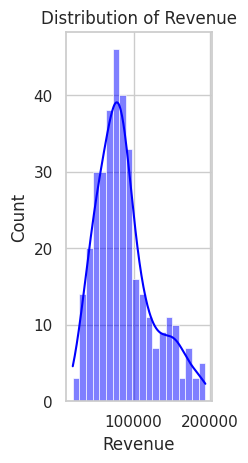

In [22]:
# Revenue Distribution
plt.subplot(1, 3, 1)
sns.histplot(df['Revenue'], bins=20, kde=True, color='blue')
plt.title('Distribution of Revenue')

Text(0.5, 1.0, 'Distribution of Profit')

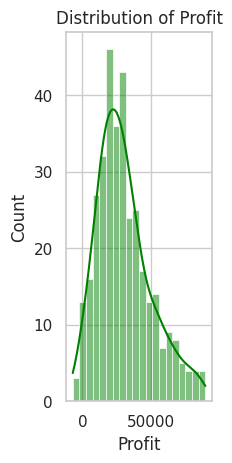

In [23]:
# Profit Distribution
plt.subplot(1, 3, 2)
sns.histplot(df['Profit'], bins=20, kde=True, color='green')
plt.title('Distribution of Profit')

Text(0.5, 1.0, 'Distribution of Customer Ratings')

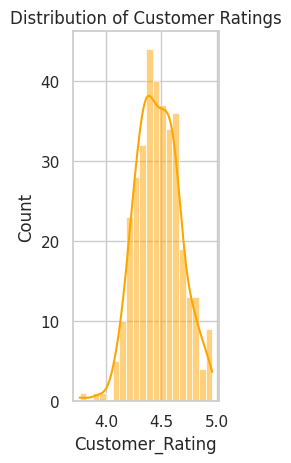

In [24]:
# Customer Rating Distribution
plt.subplot(1, 3, 3)
sns.histplot(df['Customer_Rating'], bins=20, kde=True, color='orange')
plt.title('Distribution of Customer Ratings')

In [25]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [26]:
# 5. Comparing Performance Across Categories
plt.figure(figsize=(16, 5))

<Figure size 1600x500 with 0 Axes>

<Figure size 1600x500 with 0 Axes>

/tmp/ipykernel_1732/330029212.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Store_Type', y='Revenue', errorbar=None, palette='viridis')


Text(0.5, 1.0, 'Average Revenue by Store Type')

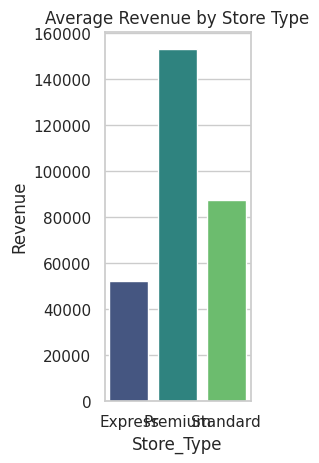

In [27]:
# Performance by Store Type
plt.subplot(1, 3, 1)
sns.barplot(data=df, x='Store_Type', y='Revenue', errorbar=None, palette='viridis')
plt.title('Average Revenue by Store Type')

/tmp/ipykernel_1732/4279908043.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Region', y='Profit', errorbar=None, palette='magma')


Text(0.5, 1.0, 'Average Profit by Region')

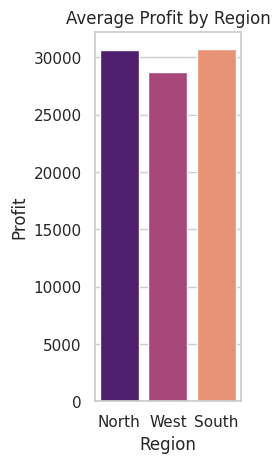

In [28]:
# Performance by Region
plt.subplot(1, 3, 2)
sns.barplot(data=df, x='Region', y='Profit', errorbar=None, palette='magma')
plt.title('Average Profit by Region')

/tmp/ipykernel_1732/3914426220.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Weather', y='Customer_Rating', palette='coolwarm')


Text(0.5, 1.0, 'Customer Ratings Across Weather Conditions')

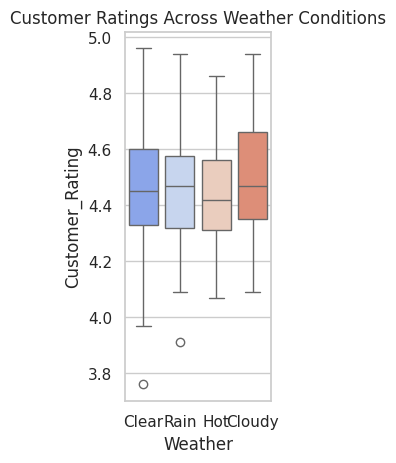

In [29]:
# Customer Ratings by Weather
plt.subplot(1, 3, 3)
sns.boxplot(data=df, x='Weather', y='Customer_Rating', palette='coolwarm')
plt.title('Customer Ratings Across Weather Conditions')

In [30]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [31]:
# 6. Correlation Analysis
# Select only numerical columns for the correlation matrix
num_cols = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = num_cols.corr()

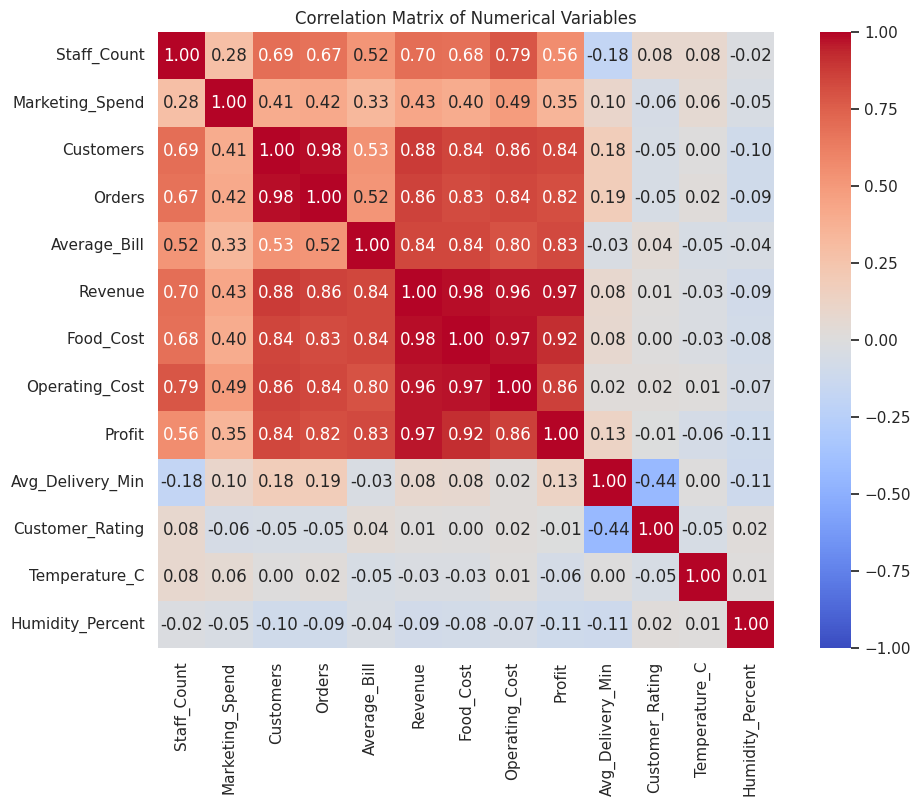

In [32]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

In [33]:
# Display top correlations with Profit specifically
print("\n--- Top Correlations with Profit ---")
print(corr_matrix['Profit'].sort_values(ascending=False))


--- Top Correlations with Profit ---
Profit              1.000000
Revenue             0.966831
Food_Cost           0.917517
Operating_Cost      0.862061
Customers           0.835993
Average_Bill        0.828444
Orders              0.815261
Staff_Count         0.559281
Marketing_Spend     0.350265
Avg_Delivery_Min    0.128512
Customer_Rating    -0.005314
Temperature_C      -0.062630
Humidity_Percent   -0.107130
Name: Profit, dtype: float64


## Meaningful Data-Driven Observations

Based on the analysis of the dataset, here are the key insights discovered during the EDA process:

*   **Store Type Dictates Financial Success:** The Premium store type significantly outperforms Express and Standard locations. Premium branches average over 152,000 in revenue compared to just 52,000 for Express branches, driven by a higher average bill and larger customer volume.
*   **Delivery Speed Impacts Customer Satisfaction:** There is a notable negative correlation (-0.44) between `Avg_Delivery_Min` and `Customer_Rating`. This indicates that as delivery times increase, customer satisfaction reliably drops, making delivery speed a critical KPI for maintaining high ratings.
*   **Consistent Profit Margins:** `Food_Cost` and `Operating_Cost` scale almost perfectly with `Revenue` (correlation > 0.96). This suggests that the restaurant branches maintain highly consistent and predictable profit margins across different scales of operation, regardless of branch size.
*   **Marketing Yields Moderate Returns:** `Marketing_Spend` shows a moderate positive correlation with `Revenue` (0.43). While increasing marketing budgets generally boosts revenue and customer acquisition, it does not guarantee a perfect 1-to-1 linear return, indicating possible diminishing returns at higher spend tiers.
*   **Regional Uniformity:** Despite individual branch variances, average financial performance is remarkably balanced across geographical territories. The North, South, and West regions all output similar average monthly revenues tightly clustered between 84,000 and 88,000.
*   **Ratings are Generally High and Resilient:** The overall `Customer_Rating` distribution is heavily left-skewed, with a mean rating of ~4.47 out of 5. Interestingly, ratings show virtually no correlation with the overall number of `Customers` (-0.04) or total `Orders`, meaning branches handle high traffic volumes without compromising service quality.